<a href="https://colab.research.google.com/github/Optimus0205/Computer-Vision/blob/main/15_Semantic_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating masked images

In [ ]:
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pycocotools import mask as coco_mask

In [ ]:
with open('/content/_annotations.coco.json') as f:
  coco_data=json.load(f)

print(coco_data)

{'info': {'year': '2026', 'version': '1', 'description': 'Exported from roboflow.com', 'contributor': '', 'url': 'https://public.roboflow.com/object-detection/undefined', 'date_created': '2026-07-06T15:47:32+00:00'}, 'licenses': [{'id': 1, 'url': 'https://creativecommons.org/licenses/by/4.0/', 'name': 'CC BY 4.0'}], 'categories': [{'id': 0, 'name': 'butterfly', 'supercategory': 'none'}, {'id': 1, 'name': 'butterfly', 'supercategory': 'butterfly'}], 'images': [{'id': 0, 'license': 1, 'file_name': 'lemon-pansy-butterfly-at-hoa-lu-vietnam_webp.rf.1b6fd5015750e1a18669483a7dda969a.jpg', 'height': 432, 'width': 432, 'date_captured': '2026-07-06T15:47:32+00:00', 'extra': {'name': 'lemon-pansy-butterfly-at-hoa-lu-vietnam.webp'}}, {'id': 1, 'license': 1, 'file_name': 'photo-1558379485-57344c39258a_jpeg.rf.403632af49d80d4999ee6b62e4e7393f.jpg', 'height': 432, 'width': 432, 'date_captured': '2026-07-06T15:47:32+00:00', 'extra': {'name': 'photo-1558379485-57344c39258a.jpeg'}}, {'id': 2, 'license':

In [5]:
image_info=coco_data['images'][0]
print(image_info)

{'id': 0, 'license': 1, 'file_name': 'lemon-pansy-butterfly-at-hoa-lu-vietnam_webp.rf.1b6fd5015750e1a18669483a7dda969a.jpg', 'height': 432, 'width': 432, 'date_captured': '2026-07-06T15:47:32+00:00', 'extra': {'name': 'lemon-pansy-butterfly-at-hoa-lu-vietnam.webp'}}


In [6]:
image_path=f'{image_info['file_name']}'
print(image_path)

lemon-pansy-butterfly-at-hoa-lu-vietnam_webp.rf.1b6fd5015750e1a18669483a7dda969a.jpg


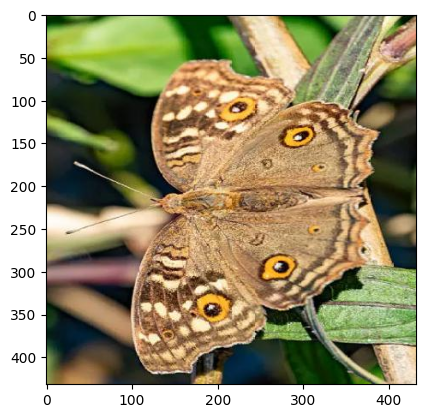

In [10]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [13]:
coco_data['annotations']

[{'id': 1,
  'image_id': 0,
  'category_id': 1,
  'bbox': [15.22, 50.79, 377, 368.95],
  'iscrowd': 0,
  'area': 139094.15,
  'segmentation': [[303.619,
    339.22,
    308.022,
    330.904,
    319.58,
    326.368,
    327.285,
    316.917,
    336.641,
    310.869,
    346.548,
    306.333,
    350.401,
    298.394,
    362.508,
    295.748,
    375.167,
    294.235,
    379.57,
    285.919,
    373.516,
    277.224,
    377.919,
    269.664,
    366.361,
    259.079,
    369.113,
    252.275,
    379.57,
    243.58,
    377.919,
    237.154,
    366.361,
    230.727,
    363.609,
    223.167,
    374.067,
    219.008,
    372.966,
    212.96,
    357.005,
    211.825,
    372.966,
    210.313,
    369.663,
    204.265,
    368.012,
    195.949,
    385.625,
    184.986,
    385.074,
    179.316,
    378.47,
    171.377,
    381.771,
    160.037,
    382.873,
    149.452,
    392.229,
    136.599,
    365.26,
    127.904,
    357.005,
    120.344,
    359.757,
    112.405,
    343.24

In [14]:
image_info

{'id': 0,
 'license': 1,
 'file_name': 'lemon-pansy-butterfly-at-hoa-lu-vietnam_webp.rf.1b6fd5015750e1a18669483a7dda969a.jpg',
 'height': 432,
 'width': 432,
 'date_captured': '2026-07-06T15:47:32+00:00',
 'extra': {'name': 'lemon-pansy-butterfly-at-hoa-lu-vietnam.webp'}}

In [16]:
annotations=[ann for ann in coco_data['annotations'] if ann['image_id']==image_info['id']]
annotations

[{'id': 1,
  'image_id': 0,
  'category_id': 1,
  'bbox': [15.22, 50.79, 377, 368.95],
  'iscrowd': 0,
  'area': 139094.15,
  'segmentation': [[303.619,
    339.22,
    308.022,
    330.904,
    319.58,
    326.368,
    327.285,
    316.917,
    336.641,
    310.869,
    346.548,
    306.333,
    350.401,
    298.394,
    362.508,
    295.748,
    375.167,
    294.235,
    379.57,
    285.919,
    373.516,
    277.224,
    377.919,
    269.664,
    366.361,
    259.079,
    369.113,
    252.275,
    379.57,
    243.58,
    377.919,
    237.154,
    366.361,
    230.727,
    363.609,
    223.167,
    374.067,
    219.008,
    372.966,
    212.96,
    357.005,
    211.825,
    372.966,
    210.313,
    369.663,
    204.265,
    368.012,
    195.949,
    385.625,
    184.986,
    385.074,
    179.316,
    378.47,
    171.377,
    381.771,
    160.037,
    382.873,
    149.452,
    392.229,
    136.599,
    365.26,
    127.904,
    357.005,
    120.344,
    359.757,
    112.405,
    343.24

In [17]:
image_info

{'id': 0,
 'license': 1,
 'file_name': 'lemon-pansy-butterfly-at-hoa-lu-vietnam_webp.rf.1b6fd5015750e1a18669483a7dda969a.jpg',
 'height': 432,
 'width': 432,
 'date_captured': '2026-07-06T15:47:32+00:00',
 'extra': {'name': 'lemon-pansy-butterfly-at-hoa-lu-vietnam.webp'}}

In [18]:
mask=np.zeros((image_info['height'],image_info['width']),dtype=np.uint8)
print(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


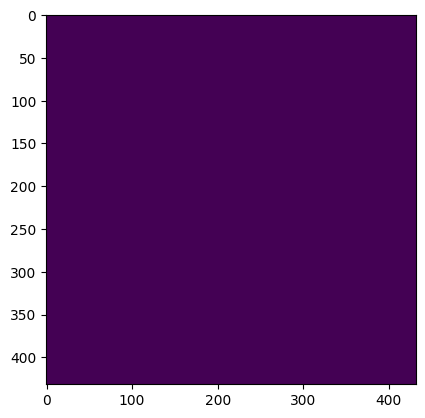

In [21]:
plt.imshow(mask)

In [24]:
segmentation=[[303.619,
    339.22,
    308.022,
    330.904,
    319.58,
    326.368,
    327.285,
    316.917,
    336.641,
    310.869,
    346.548,
    306.333,
    350.401,
    298.394,
    362.508,
    295.748,
    375.167,
    294.235,
    379.57,
    285.919,
    373.516,
    277.224,
    377.919,
    269.664,
    366.361,
    259.079,
    369.113,
    252.275,
    379.57,
    243.58,
    377.919,
    237.154,
    366.361,
    230.727,
    363.609,
    223.167,
    374.067,
    219.008,
    372.966,
    212.96,
    357.005,
    211.825,
    372.966,
    210.313,
    369.663,
    204.265,
    368.012,
    195.949,
    385.625,
    184.986,
    385.074,
    179.316,
    378.47,
    171.377,
    381.771,
    160.037,
    382.873,
    149.452,
    392.229,
    136.599,
    365.26,
    127.904,
    357.005,
    120.344,
    359.757,
    112.405,
    343.246,
    105.222,
    328.936,
    102.198,
    322.882,
    98.04,
    305.271,
    100.686,
    287.108,
    107.491,
    282.154,
    107.491,
    293.712,
    94.638,
    288.209,
    88.212,
    278.302,
    80.651,
    276.651,
    75.737,
    267.295,
    73.09,
    249.683,
    71.578,
    237.574,
    70.822,
    227.118,
    68.554,
    220.513,
    64.396,
    217.211,
    58.347,
    221.063,
    53.433,
    214.459,
    50.787,
    166.026,
    51.165,
    155.57,
    55.701,
    135.205,
    87.078,
    123.648,
    119.21,
    123.648,
    146.806,
    132.453,
    183.096,
    148.964,
    203.131,
    153.918,
    208.046,
    144.012,
    208.046,
    137.957,
    212.204,
    131.904,
    212.582,
    36.69,
    166.463,
    26.232,
    175.913,
    127.5,
    219.386,
    15.225,
    254.543,
    20.728,
    259.835,
    131.904,
    225.435,
    136.857,
    228.081,
    145.112,
    231.862,
    150.616,
    232.617,
    155.57,
    232.239,
    134.105,
    249.251,
    119.795,
    268.53,
    106.586,
    299.15,
    99.431,
    336.196,
    99.982,
    377.779,
    107.137,
    399.705,
    117.043,
    415.96,
    124.198,
    419.74,
    171.53,
    419.361,
    172.63,
    406.887,
    180.886,
    397.436,
    192.444,
    393.278,
    199.599,
    388.741,
    211.707,
    389.876,
    214.459,
    387.986,
    222.714,
    383.449,
    238.676,
    384.962,
    244.729,
    377.779,
    244.729,
    369.462,
    253.535,
    366.06,
    259.039,
    358.878,
    252.435,
    349.427,
    248.148,
    337.897,
    271.147,
    346.403,
    280.503,
    346.403,
    289.86,
    341.866,
    303.619,
    339.22]]

In [25]:
for seg in segmentation:
    print(np.array(seg).reshape((len(seg)//2,2)))

[[303.619 339.22 ]
 [308.022 330.904]
 [319.58  326.368]
 [327.285 316.917]
 [336.641 310.869]
 [346.548 306.333]
 [350.401 298.394]
 [362.508 295.748]
 [375.167 294.235]
 [379.57  285.919]
 [373.516 277.224]
 [377.919 269.664]
 [366.361 259.079]
 [369.113 252.275]
 [379.57  243.58 ]
 [377.919 237.154]
 [366.361 230.727]
 [363.609 223.167]
 [374.067 219.008]
 [372.966 212.96 ]
 [357.005 211.825]
 [372.966 210.313]
 [369.663 204.265]
 [368.012 195.949]
 [385.625 184.986]
 [385.074 179.316]
 [378.47  171.377]
 [381.771 160.037]
 [382.873 149.452]
 [392.229 136.599]
 [365.26  127.904]
 [357.005 120.344]
 [359.757 112.405]
 [343.246 105.222]
 [328.936 102.198]
 [322.882  98.04 ]
 [305.271 100.686]
 [287.108 107.491]
 [282.154 107.491]
 [293.712  94.638]
 [288.209  88.212]
 [278.302  80.651]
 [276.651  75.737]
 [267.295  73.09 ]
 [249.683  71.578]
 [237.574  70.822]
 [227.118  68.554]
 [220.513  64.396]
 [217.211  58.347]
 [221.063  53.433]
 [214.459  50.787]
 [166.026  51.165]
 [155.57   5

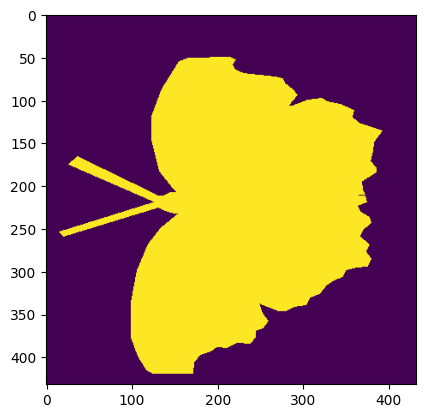

In [43]:
def create_binary_mask(segmentation, image_height,image_width):
    mask_temp=np.zeros((image_height,image_width),dtype=np.uint8)
    for seg in segmentation:
        poly=np.array(seg).reshape((len(seg)//2,2))
        cv2.fillPoly(mask_temp,[np.int32(poly)],1)

    plt.imshow(mask_temp)
    return mask_temp


for ann in annotations:
    # You need to got through the annotations and creat a mask
    # update the mask
    binary_mask=create_binary_mask(ann['segmentation'],image_info['height'],image_info['width'])
    mask=np.maximum(mask,binary_mask)

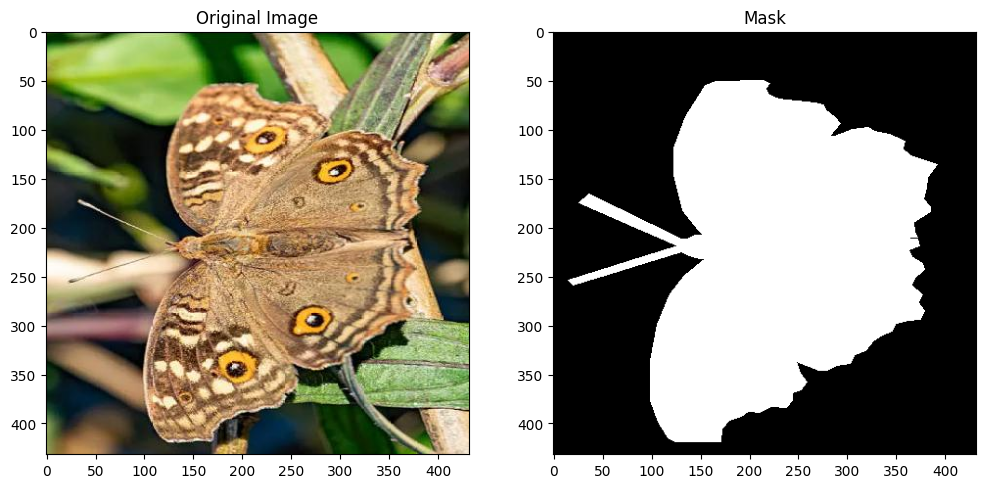

In [28]:
# Visualize the mask
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(mask,cmap='gray')
plt.title('Mask')

plt.show()

In [29]:
cv2.imwrite('masked_image.png',mask)

True

All black bcz cv2 normalized

In [30]:
# Scale the mask to 0->255 for visibility
mask_scaled=mask*255

cv2.imwrite('new_masked_image.png',mask_scaled)

True

Mask saved successfully at /content//photo-1560263816-d704d83cce0f-1-_jpeg_mask.png


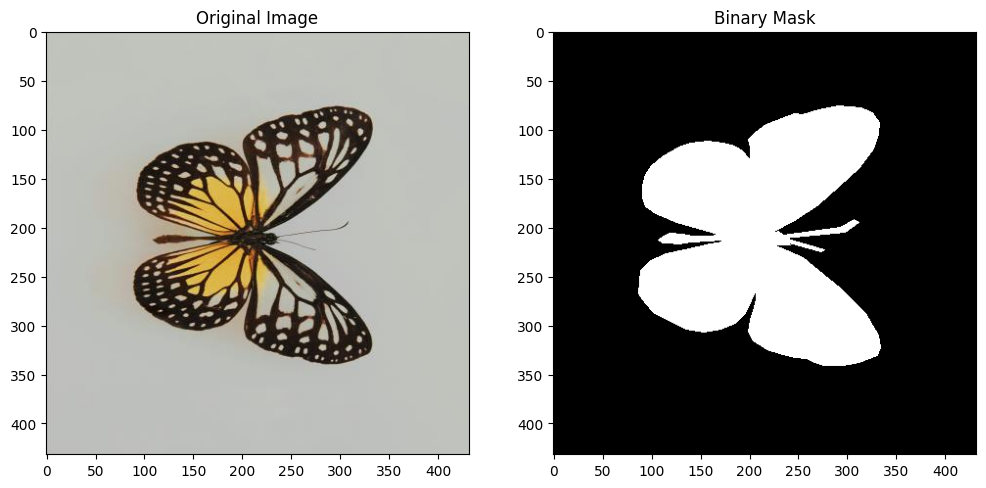

In [34]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

class COCOProcessor:
    def __init__(self, coco_annotation_file, image_dir):
        '''
        Initialize the processor with the COCO annotation and image directory.
        :param coco_annotation_file: Path to the COCO annotation file.
        :param image_dir: Directory containing the images.
        '''
        self.coco_annotation_file = coco_annotation_file
        self.image_dir = image_dir
        self.coco_data = self._load_coco_annotations()


    def _load_coco_annotations(self):
        '''
        Load the COCO annotations from the JSON file.
        :return: Dictionary containing the COCO data.
        '''
        try:
            with open(self.coco_annotation_file, 'r') as f:
                coco_data = json.load(f)
            return coco_data
        except FileNotFoundError:
            print(f"Error: COCO annotation file '{self.coco_annotation_file}'not found.")
            raise

    def create_binary_mask(self, segmentation, image_height, image_width):
        '''
        Create a binary mask from the given segmentation.
        '''
        mask=np.zeros((image_height,image_width),dtype=np.uint8)
        for seg in segmentation:
            poly=np.array(seg).reshape((len(seg)//2,2))
            cv2.fillPoly(mask,[np.int32(poly)],1)
        return mask

    def save_mask(self,mask,image_info):
        mask_scaled=mask*255
        mask_save_path=f'{self.image_dir}/{image_info['file_name'].split('.')[0]}_mask.png'

        cv2.imwrite(mask_save_path,mask_scaled)

        print(f'Mask saved successfully at {mask_save_path}')
        return mask_save_path

    def process_image(self,image_id):
        # get image_info by image_id
        image_info=self.coco_data['images'][image_id]
        image_path=f'{self.image_dir}/{image_info["file_name"]}'
        # load the image
        image=cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Image File {image_info['file_name']} not found in sirectory {self.image_dir}.")
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)  # Convert to RGB

        # Get annotations for the image
        annotations=[ann for ann in self.coco_data['annotations'] if ann['image_id']==image_info['id']]

        # Create the binary mask
        mask=np.zeros((image_info['height'],image_info['width']),dtype=np.uint8)
        for ann in annotations:
            binary_mask=self.create_binary_mask(ann['segmentation'],image_info['height'],image_info['width'])
            mask=np.maximum(mask,binary_mask)    # Merge all mask

        # Save the mask
        mask_save_path=self.save_mask(mask,image_info)

        # Visualize the original img and mask
        self.visualize_mask(image,mask_save_path)

    def visualize_mask(self,image,mask_save_path):
        # Load the saved mask
        saved_mask=cv2.imread(mask_save_path,cv2.IMREAD_GRAYSCALE)
        # Visualize the mask
        plt.figure(figsize=(12,6))

        plt.subplot(1,2,1)
        plt.imshow(image)
        plt.title('Original Image')

        plt.subplot(1,2,2)
        plt.imshow(saved_mask,cmap='gray')
        plt.title('Binary Mask')

        plt.show()


# Example usage
if __name__ == "__main__":
    coco_annotation_file = '/content/_annotations.coco.json'
    image_dir = '/content/' # Corrected image directory

    coco_processor = COCOProcessor(coco_annotation_file, image_dir)
    coco_processor.process_image(5)

In [35]:
cv2.imwrite('masked_image.png',mask)

True

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
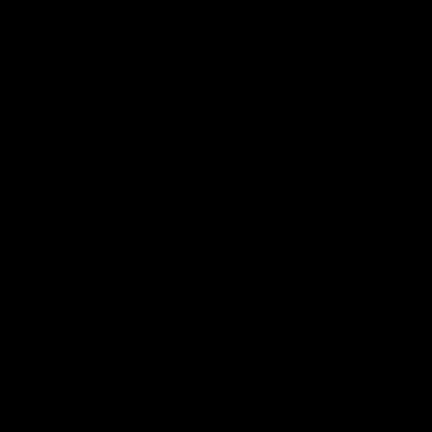

In [36]:
mask

In [37]:
np.unique(mask)

array([0, 1], dtype=uint8)

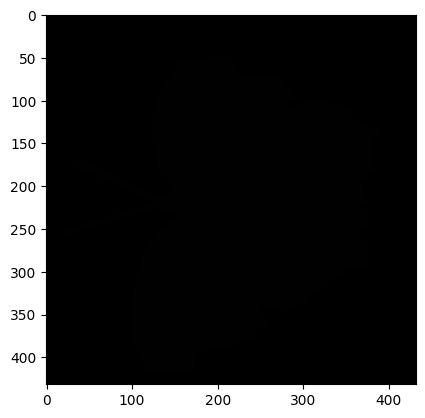

In [38]:
plt.imshow(cv2.imread('masked_image.png'))

In [39]:
mask_scaled=mask*255

cv2.imwrite('new_masked_scaled.png',mask_scaled)

True

In [40]:
np.unique(cv2.imread('new_maked_scaled.png'))

array([None], dtype=object)

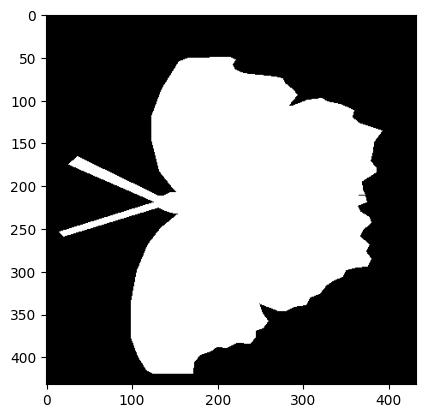

In [42]:
plt.imshow(cv2.imread('new_masked_scaled.png'))